# 📊 Deep-Dive Analysis & Interactive Dashboarding

## Objective
To perform advanced business analysis on Adidas sales data and build an interactive dashboard for KPI tracking and business insights.

In [11]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.cluster import KMeans

sns.set(style="whitegrid")

## 📌 Load Dataset

In [2]:
df = pd.read_csv("../data/adidas_sales.csv")

df.head()

,Unnamed: 0,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,NaN,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,in-store
1,NaN,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,in-store
2,NaN,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,in-store
3,NaN,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,in-store
4,NaN,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,in-store


## 📌 Understanding Dataset

In [3]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        0 non-null      float64
 1   Retailer          9648 non-null   object 
 2   Retailer ID       9648 non-null   int64  
 3   Invoice Date      9648 non-null   object 
 4   Region            9648 non-null   object 
 5   State             9648 non-null   object 
 6   City              9648 non-null   object 
 7   Product           9648 non-null   object 
 8   Price per Unit    9648 non-null   float64
 9   Units Sold        9648 non-null   int64  
 10  Total Sales       9648 non-null   float64
 11  Operating Profit  9648 non-null   float64
 12  Operating Margin  9648 non-null   float64
 13  Sales Method      9648 non-null   object 
dtypes: float64(5), int64(2), object(7)
memory usage: 1.0+ MB


Unnamed: 0          9648
Retailer               0
Retailer ID            0
Invoice Date           0
Region                 0
State                  0
City                   0
Product                0
Price per Unit         0
Units Sold             0
Total Sales            0
Operating Profit       0
Operating Margin       0
Sales Method           0
dtype: int64

# 📌 Core KPI Analysis

In this step, we define important business KPIs:
- Total Sales
- Total Profit
- Average Operating Margin
- Units Sold
- Top Product

In [4]:
total_sales = df['Total Sales'].sum()

total_profit = df['Operating Profit'].sum()

total_units = df['Units Sold'].sum()

avg_margin = df['Operating Margin'].mean()

top_product = df.groupby('Product')['Total Sales'].sum().idxmax()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Units Sold:", total_units)
print("Average Operating Margin:", avg_margin)
print("Top Product:", top_product)

Total Sales: 899902125.0
Total Profit: 332134761.45000005
Total Units Sold: 2478861
Average Operating Margin: 0.42299129353233833
Top Product: Men's Street Footwear


## 📌 KPI Visualization

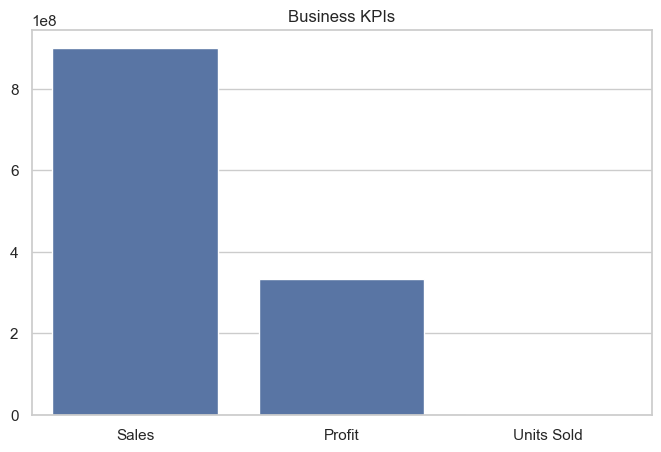

In [5]:
kpis = ['Sales', 'Profit', 'Units Sold']

values = [total_sales, total_profit, total_units]

plt.figure(figsize=(8,5))

sns.barplot(x=kpis, y=values)

plt.title("Business KPIs")

plt.show()

# 📌 Regional Sales Analysis

This helps identify high-performing regions.

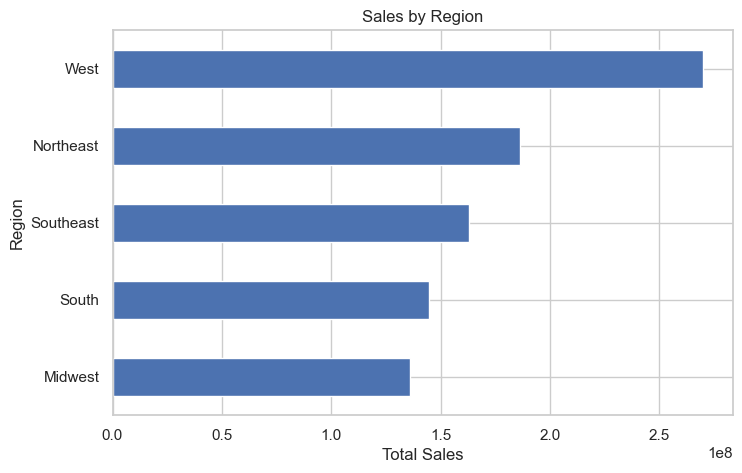

In [6]:
region_sales = df.groupby('Region')['Total Sales'].sum().sort_values()

plt.figure(figsize=(8,5))

region_sales.plot(kind='barh')

plt.title("Sales by Region")

plt.xlabel("Total Sales")

plt.show()

# 📌 Product Performance Analysis

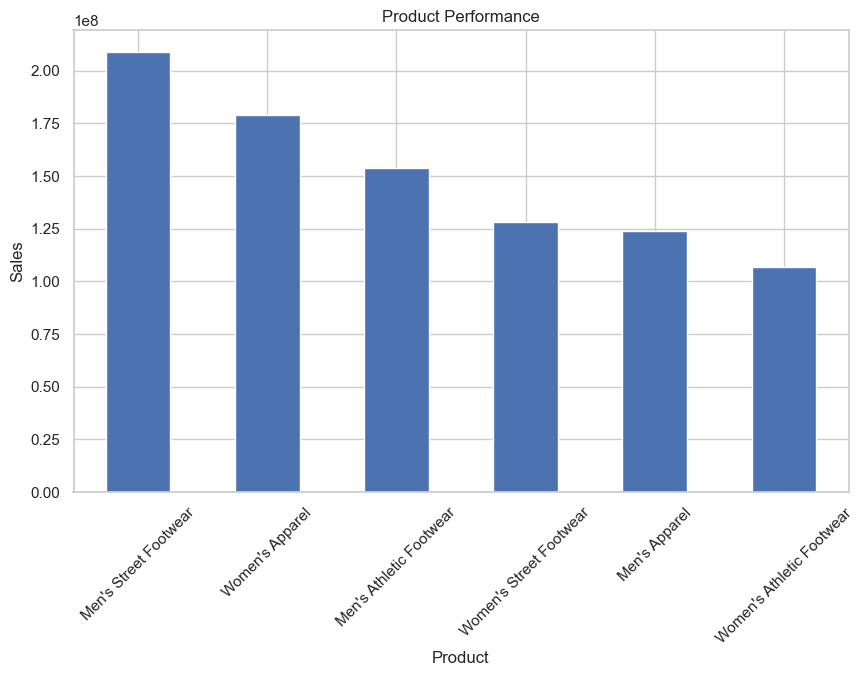

In [7]:
top_products = df.groupby('Product')['Total Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

top_products.plot(kind='bar')

plt.title("Product Performance")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

# 📌 Monthly Sales Trend Analysis

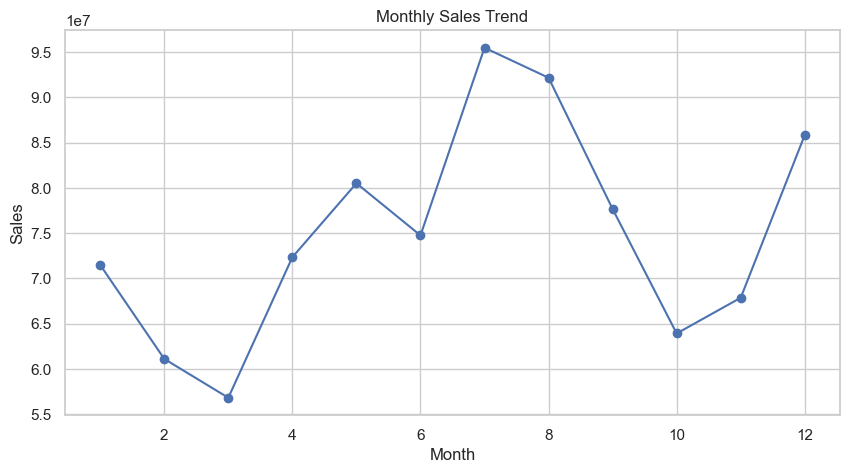

In [8]:
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])

df['Month'] = df['Invoice Date'].dt.month

monthly_sales = df.groupby('Month')['Total Sales'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

# 📌 Customer Segmentation using K-Means Clustering

We group customers based on:
- Units Sold
- Total Sales
- Operating Profit

In [9]:
cluster_data = df[['Units Sold', 'Total Sales', 'Operating Profit']]

cluster_data = cluster_data.dropna()

In [12]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(cluster_data)

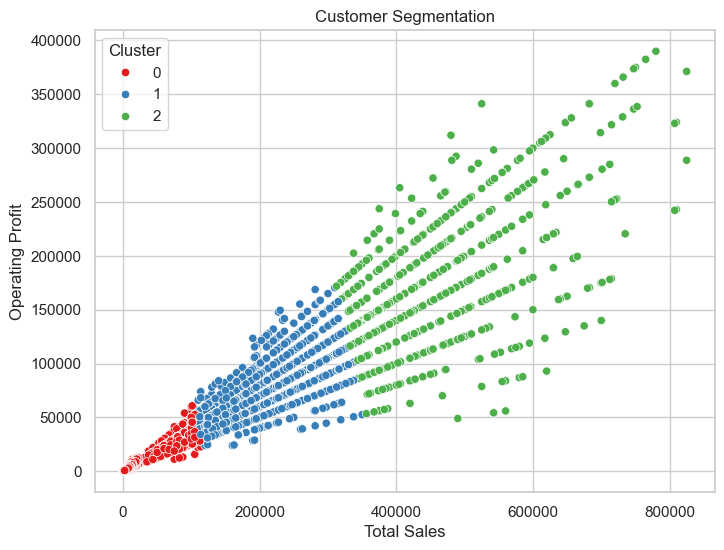

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Total Sales'],
    y=df['Operating Profit'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Customer Segmentation")

plt.show()

# 📌 Interactive Dashboard Visualizations

In [14]:
fig = px.bar(
    df,
    x='Region',
    y='Total Sales',
    color='Product',
    title='Interactive Sales Dashboard'
)

fig.show()

In [15]:
fig = px.pie(
    df,
    names='Region',
    values='Total Sales',
    title='Regional Sales Contribution'
)

fig.show()

In [16]:
fig = px.line(
    monthly_sales,
    title='Monthly Sales Trend'
)

fig.show()

# 📌 Exporting Analysis Results

In [17]:
region_sales.to_csv("../outputs/region_sales.csv")

top_products.to_csv("../outputs/top_products.csv")

# 📌 Final Business Insights

## Key Findings

- Footwear products generate highest revenue
- West region contributes maximum sales
- Sales increase during seasonal periods
- Higher sales strongly impact profitability
- Customer segmentation reveals different purchasing behaviors

---

# 📌 Conclusion

This deep-dive analysis helped identify major business drivers and customer patterns.  
Interactive dashboards provide better visibility into KPIs and business performance.